# SegFormer-B0 Training (3000 images)

SegFormer-B0を使用した6クラスセマンティックセグメンテーション学習。

## 設定
- **モデル**: SegFormer-B0 (nvidia/segformer-b0-finetuned-ade-512-512)
- **データセット**: 3000枚 (ID 0-2999) - XMLから直接読み込み
- **分割**: Patient-based split (SEED=42, VAL_RATIO=0.2)
- **Augmentation**: ±180度回転
- **学習**: 最大1000エポック、Early Stopping 20エポック

## 6クラス定義
| Class ID | Name | Description |
|----------|------|-------------|
| 0 | background | 背景 |
| 1 | conjunctiva | 結膜/眼瞼 |
| 2 | iris_vis | 虹彩（可視部分 - eyelid内） |
| 3 | iris_occ | 虹彩（遮蔽部分 - eyelid外） |
| 4 | pupil_vis | 瞳孔（可視部分 - eyelid内） |
| 5 | pupil_occ | 瞳孔（遮蔽部分 - eyelid外） |

In [3]:
# ===== Cell 1: Imports =====
import json
import math
import random
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3080 Ti Laptop GPU


In [4]:
# ===== Cell 2: Configuration =====
# Paths
PROJECT_ROOT = Path(".").resolve()
IMAGES_DIR = PROJECT_ROOT / "Images" / "images"
XML_EYELID = PROJECT_ROOT / "Images" / "eyelid_caruncle_seg_0-3000.xml"
XML_IRIS_PUPIL = PROJECT_ROOT / "Images" / "obb_iris_pupil_1-3000.xml"

OUTPUT_DIR = PROJECT_ROOT / "Ablation_SegFormerB0"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = OUTPUT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Data settings
IMAGE_SIZE = 512
NUM_CLASSES = 6
SEED = 42
VAL_RATIO = 0.2
MIN_IMAGE_ID = 0
MAX_IMAGE_ID = 2999  # ID 0-2999 = 3000 images

# Training settings
BATCH_SIZE = 8
NUM_EPOCHS = 1000
EARLY_STOP_PATIENCE = 20
LEARNING_RATE = 6e-5
WEIGHT_DECAY = 0.01
NUM_WORKERS = 0  # Windows compatibility
PIN_MEMORY = True

# Augmentation settings
ROTATION_DEGREE = 180  # Maximum rotation angle

# Model settings
SEGFORMER_MODEL_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"

# Ellipse settings
ELLIPSE_NUM_POINTS = 100
EYELID_INSIDE_IS_VISIBLE = True  # eyelid内 = visible

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuration:")
print(f"  Model: {SEGFORMER_MODEL_NAME}")
print(f"  Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Image ID range: {MIN_IMAGE_ID}-{MAX_IMAGE_ID}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Early stopping: {EARLY_STOP_PATIENCE} epochs")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Rotation augmentation: +/-{ROTATION_DEGREE} degrees")
print(f"  Device: {device}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Model: nvidia/segformer-b0-finetuned-ade-512-512
  Image size: 512x512
  Image ID range: 0-2999
  Batch size: 8
  Max epochs: 1000
  Early stopping: 20 epochs
  Learning rate: 6e-05
  Rotation augmentation: +/-180 degrees
  Device: cuda
  Output: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0


In [5]:
# ===== Cell 3: XML Parsing Functions =====
def _parse_points_attr(points_str: str):
    """CVAT polygon points='x,y;x,y;...' -> [(x0,y0), (x1,y1), ...]"""
    pts = []
    for token in points_str.strip().split(";"):
        token = token.strip()
        if not token:
            continue
        x_str, y_str = token.split(",")
        pts.append((float(x_str), float(y_str)))
    return pts


def _ellipse_to_points(cx, cy, rx, ry, rotation_deg, n=100):
    """Ellipse parameters -> list of (x, y) points"""
    theta = math.radians(rotation_deg % 360.0)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)
    
    points = []
    for i in range(n):
        a = 2.0 * math.pi * (i / n)
        ca = math.cos(a)
        sa = math.sin(a)
        
        x0 = rx * ca
        y0 = ry * sa
        x = cx + x0 * cos_t - y0 * sin_t
        y = cy + x0 * sin_t + y0 * cos_t
        points.append((x, y))
    
    return points


def load_cvat_image_names(xml_path: Path, min_id: int, max_id: int):
    """Load image names from CVAT XML within ID range."""
    if not xml_path.exists():
        return {}
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    result = {}
    
    for img_el in root.findall(".//image"):
        img_id_str = img_el.get("id")
        name = img_el.get("name")
        if img_id_str is not None and name:
            try:
                img_id = int(img_id_str)
                if min_id <= img_id <= max_id:
                    result[img_id] = Path(name).name
            except ValueError:
                continue
    return result


def load_cvat_polygons_by_image(xml_path: Path):
    """CVAT XML(polygon) -> {image_name: [(label, points), ...]}"""
    out = {}
    if not xml_path.exists():
        return out
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    
    for img in root.findall("image"):
        name = img.get("name")
        if not name:
            continue
        name = Path(name).name
        items = []
        for poly in img.findall("polygon"):
            label = poly.get("label")
            pts = poly.get("points")
            if not label or not pts:
                continue
            items.append((label, _parse_points_attr(pts)))
        if items:
            out[name] = items
    return out


def load_cvat_ellipses_by_image(xml_path: Path):
    """CVAT XML(ellipse) -> {image_name: [(label, cx, cy, rx, ry, rot), ...]}"""
    out = {}
    if not xml_path.exists():
        return out
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    
    for img in root.findall("image"):
        name = img.get("name")
        if not name:
            continue
        name = Path(name).name
        items = []
        for el in img.findall("ellipse"):
            label = el.get("label")
            if not label:
                continue
            try:
                cx = float(el.get("cx"))
                cy = float(el.get("cy"))
                rx = float(el.get("rx"))
                ry = float(el.get("ry"))
            except Exception:
                continue
            rot = float(el.get("rotation")) if el.get("rotation") is not None else 0.0
            items.append((label, cx, cy, rx, ry, rot))
        if items:
            out[name] = items
    return out


print("XML parsing functions defined.")

XML parsing functions defined.


In [6]:
# ===== Cell 4: Load XML Annotations =====
# Load image names from both XML files
eyelid_dict = load_cvat_image_names(XML_EYELID, MIN_IMAGE_ID, MAX_IMAGE_ID)
iris_dict = load_cvat_image_names(XML_IRIS_PUPIL, MIN_IMAGE_ID, MAX_IMAGE_ID)

# Union of all images
all_dict = {**eyelid_dict, **iris_dict}

# Load annotations
EYELID_POLYS_BY_IMAGE = load_cvat_polygons_by_image(XML_EYELID)
ELLIPSES_BY_IMAGE = load_cvat_ellipses_by_image(XML_IRIS_PUPIL)

# Filter to images that exist on disk
image_names = []
missing_images = 0

for img_id in sorted(all_dict.keys()):
    name = all_dict[img_id]
    img_path = IMAGES_DIR / name
    if not img_path.exists():
        missing_images += 1
        continue
    image_names.append(name)

print(f"XML eyelid images (ID {MIN_IMAGE_ID}-{MAX_IMAGE_ID}): {len(eyelid_dict)}")
print(f"XML iris/pupil images (ID {MIN_IMAGE_ID}-{MAX_IMAGE_ID}): {len(iris_dict)}")
print(f"Union: {len(all_dict)}")
print(f"Missing image files: {missing_images}")
print(f"Total valid images: {len(image_names)}")
print(f"\nAnnotation counts:")
print(f"  Images with eyelid polygons: {len(EYELID_POLYS_BY_IMAGE)}")
print(f"  Images with iris/pupil ellipses: {len(ELLIPSES_BY_IMAGE)}")

XML eyelid images (ID 0-2999): 2990
XML iris/pupil images (ID 0-2999): 3000
Union: 3000
Missing image files: 0
Total valid images: 3000

Annotation counts:
  Images with eyelid polygons: 4443
  Images with iris/pupil ellipses: 2971


In [7]:
# ===== Cell 5: Train/Val Split (Patient-based) =====
def subject_id_from_name(name: str) -> str:
    """Extract subject ID from image name (e.g., '001-L-01.png' -> '001')"""
    return str(name).split('-', 1)[0]

# Get unique subjects
subjects = sorted({subject_id_from_name(n) for n in image_names})
rng = random.Random(SEED)
rng.shuffle(subjects)

# Split by subjects
num_val = max(1, int(len(subjects) * VAL_RATIO))
val_subjects = set(subjects[:num_val])

train_names = [n for n in image_names if subject_id_from_name(n) not in val_subjects]
val_names = [n for n in image_names if subject_id_from_name(n) in val_subjects]

print(f"Train images: {len(train_names)}")
print(f"Val images: {len(val_names)}")
print(f"Train subjects: {len({subject_id_from_name(n) for n in train_names})}")
print(f"Val subjects: {len(val_subjects)}")

Train images: 2426
Val images: 574
Train subjects: 156
Val subjects: 38


In [8]:
# ===== Cell 6: Mask Generation from XML =====
def generate_sixcls_mask_from_xml(image_name, h, w, eyelid_polys_dict, ellipses_dict):
    """
    Generate 6-class semantic segmentation mask from XML annotations.
    
    Classes:
        0: background
        1: conjunctiva/eyelid
        2: iris_vis (inside eyelid)
        3: iris_occ (outside eyelid)
        4: pupil_vis (inside eyelid)
        5: pupil_occ (outside eyelid)
    
    Returns:
        mask: (H, W) numpy array with class IDs 0-5
    """
    mask = np.zeros((h, w), dtype=np.uint8)
    
    # Step 1: Create eyelid mask
    eyelid_mask = np.zeros((h, w), dtype=np.uint8)
    for label, points in eyelid_polys_dict.get(image_name, []):
        if label in ('Eyelid', 'Caruncle'):
            pts = np.array(points, dtype=np.float32).reshape(-1, 2)
            pts_i = np.round(pts).astype(np.int32)
            cv2.fillPoly(eyelid_mask, [pts_i], 255)
    
    # Step 2: Create iris and pupil masks (full ellipse)
    iris_full_mask = np.zeros((h, w), dtype=np.uint8)
    pupil_full_mask = np.zeros((h, w), dtype=np.uint8)
    
    for label, cx, cy, rx, ry, rot in ellipses_dict.get(image_name, []):
        points = _ellipse_to_points(cx, cy, rx, ry, rot, n=ELLIPSE_NUM_POINTS)
        pts = np.array(points, dtype=np.float32).reshape(-1, 2)
        pts_i = np.round(pts).astype(np.int32)
        
        if label == 'Iris':
            cv2.fillPoly(iris_full_mask, [pts_i], 255)
        elif label == 'Pupil':
            cv2.fillPoly(pupil_full_mask, [pts_i], 255)
    
    # Step 3: Split iris/pupil into vis/occ based on eyelid
    eyelid_inv = cv2.bitwise_not(eyelid_mask)
    
    if EYELID_INSIDE_IS_VISIBLE:
        iris_vis_mask = cv2.bitwise_and(iris_full_mask, eyelid_mask)
        iris_occ_mask = cv2.bitwise_and(iris_full_mask, eyelid_inv)
        pupil_vis_mask = cv2.bitwise_and(pupil_full_mask, eyelid_mask)
        pupil_occ_mask = cv2.bitwise_and(pupil_full_mask, eyelid_inv)
    else:
        iris_vis_mask = cv2.bitwise_and(iris_full_mask, eyelid_inv)
        iris_occ_mask = cv2.bitwise_and(iris_full_mask, eyelid_mask)
        pupil_vis_mask = cv2.bitwise_and(pupil_full_mask, eyelid_inv)
        pupil_occ_mask = cv2.bitwise_and(pupil_full_mask, eyelid_mask)
    
    # Step 4: Build 6-class mask (order matters for overlaps)
    # Background is 0 by default
    # Class 1: conjunctiva (eyelid area, excluding iris and pupil)
    conj_mask = eyelid_mask.copy()
    conj_mask[iris_full_mask > 0] = 0
    conj_mask[pupil_full_mask > 0] = 0
    mask[conj_mask > 0] = 1
    
    # Class 2: iris_vis
    mask[iris_vis_mask > 0] = 2
    
    # Class 3: iris_occ
    mask[iris_occ_mask > 0] = 3
    
    # Class 4: pupil_vis (overwrites iris where pupil exists)
    mask[pupil_vis_mask > 0] = 4
    
    # Class 5: pupil_occ
    mask[pupil_occ_mask > 0] = 5
    
    return mask


# Test mask generation (at original resolution, then resize)
test_name = image_names[0]
test_img = cv2.imread(str(IMAGES_DIR / test_name))
test_orig_h, test_orig_w = test_img.shape[:2]
test_mask = generate_sixcls_mask_from_xml(test_name, test_orig_h, test_orig_w, 
                                          EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE)
test_mask_resized = cv2.resize(test_mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

print(f"Test mask for {test_name}:")
print(f"  Original size: {test_orig_w}x{test_orig_h}")
print(f"  Resized to: {IMAGE_SIZE}x{IMAGE_SIZE}")
unique, counts = np.unique(test_mask_resized, return_counts=True)
for u, c in zip(unique, counts):
    class_names = ['background', 'conjunctiva', 'iris_vis', 'iris_occ', 'pupil_vis', 'pupil_occ']
    print(f"  Class {u} ({class_names[u]}): {c} pixels ({100*c/(IMAGE_SIZE*IMAGE_SIZE):.1f}%)")

Test mask for 1-20141126-38-091804_eb568e2ac952f8be45ec0ac9ae800120b7c988b60ac499ca87306986d218f554_L.jpg:
  Original size: 956x956
  Resized to: 512x512
  Class 0 (background): 241592 pixels (92.2%)
  Class 1 (conjunctiva): 3254 pixels (1.2%)
  Class 2 (iris_vis): 5210 pixels (2.0%)
  Class 3 (iris_occ): 10874 pixels (4.1%)
  Class 4 (pupil_vis): 144 pixels (0.1%)
  Class 5 (pupil_occ): 1070 pixels (0.4%)


In [9]:
# ===== Cell 7: Dataset Definition =====
class EyeSegmentationDataset(Dataset):
    """
    Dataset for SegFormer 6-class segmentation.
    Generates masks from XML annotations on-the-fly.
    """
    
    def __init__(self, image_names, images_dir, eyelid_polys_dict, ellipses_dict,
                 image_size=512, augment=False, rotation_degree=180):
        self.image_names = image_names
        self.images_dir = Path(images_dir)
        self.eyelid_polys_dict = eyelid_polys_dict
        self.ellipses_dict = ellipses_dict
        self.image_size = image_size
        self.augment = augment
        self.rotation_degree = rotation_degree
        
        # SegFormer image processor
        self.processor = SegformerImageProcessor.from_pretrained(
            SEGFORMER_MODEL_NAME,
            do_resize=False,
            do_rescale=True,
            do_normalize=True
        )
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        name = self.image_names[idx]
        
        # Load image
        img_path = self.images_dir / name
        img = cv2.imread(str(img_path))
        orig_h, orig_w = img.shape[:2]
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        
        # Generate mask from XML (at original resolution, then resize)
        gt_mask = generate_sixcls_mask_from_xml(
            name, orig_h, orig_w, 
            self.eyelid_polys_dict, self.ellipses_dict
        )
        gt_mask = cv2.resize(gt_mask, (self.image_size, self.image_size), 
                            interpolation=cv2.INTER_NEAREST)
        
        # Augmentation: Random rotation
        if self.augment and self.rotation_degree > 0:
            angle = random.uniform(-self.rotation_degree, self.rotation_degree)
            img_pil = Image.fromarray(img)
            label_pil = Image.fromarray(gt_mask)
            img_pil = img_pil.rotate(angle, resample=Image.BILINEAR, expand=False)
            label_pil = label_pil.rotate(angle, resample=Image.NEAREST, expand=False)
            img = np.array(img_pil)
            gt_mask = np.array(label_pil)
        
        # SegFormer preprocessing
        inputs = self.processor(images=img, return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)
        
        labels = torch.from_numpy(gt_mask).long()
        
        return {
            "pixel_values": pixel_values,
            "labels": labels,
            "name": name
        }


# Create datasets
train_ds = EyeSegmentationDataset(
    train_names, IMAGES_DIR, EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE,
    image_size=IMAGE_SIZE, augment=True, rotation_degree=ROTATION_DEGREE
)
val_ds = EyeSegmentationDataset(
    val_names, IMAGES_DIR, EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE,
    image_size=IMAGE_SIZE, augment=False
)

print(f"Train dataset: {len(train_ds)} samples")
print(f"Val dataset: {len(val_ds)} samples")
print(f"Total: {len(train_ds) + len(val_ds)} samples")

c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Train dataset: 2426 samples
Val dataset: 574 samples
Total: 3000 samples


In [10]:
# ===== Cell 8: Model Definition =====
def create_segformer_model(num_classes=6):
    """Create SegFormer-B0 model for 6-class segmentation."""
    model = SegformerForSemanticSegmentation.from_pretrained(
        SEGFORMER_MODEL_NAME,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )
    return model


class SegFormerLoss(nn.Module):
    """Combined Cross Entropy + Dice Loss for SegFormer"""
    
    def __init__(self, use_dice=True, dice_weight=0.5):
        super().__init__()
        self.use_dice = use_dice
        self.dice_weight = dice_weight
        self.ce_loss = nn.CrossEntropyLoss()
    
    def dice_loss(self, pred, target, num_classes):
        """Multi-class Dice loss"""
        pred_softmax = F.softmax(pred, dim=1)
        target_onehot = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()
        
        intersection = (pred_softmax * target_onehot).sum(dim=(2, 3))
        union = pred_softmax.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))
        
        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        return 1 - dice.mean()
    
    def forward(self, logits, labels):
        if logits.shape[-2:] != labels.shape[-2:]:
            logits = F.interpolate(
                logits, size=labels.shape[-2:],
                mode="bilinear", align_corners=False
            )
        
        ce = self.ce_loss(logits, labels)
        
        if self.use_dice:
            dice = self.dice_loss(logits, labels, logits.shape[1])
            return ce * (1 - self.dice_weight) + dice * self.dice_weight
        return ce


print("Model and loss function defined.")

Model and loss function defined.


In [12]:
# ===== Cell 9: Training Functions =====
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    
    return total_loss / len(loader)


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
    
    return total_loss / len(loader)


print("Training functions defined.")

Training functions defined.


In [ ]:
# ===== Cell 10: Run Training =====
# Create data loaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

# Create model
model = create_segformer_model(num_classes=NUM_CLASSES).to(device)
criterion = SegFormerLoss(use_dice=True, dice_weight=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = GradScaler()

# Training loop
best_val_loss = float("inf")
patience_counter = 0
train_losses = []
val_losses = []
best_epoch = 0

print(f"\nStarting training...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'Best':>6} {'Status':>15}")
print("-" * 55)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    epoch_time = time.time() - epoch_start
    
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        
        save_path = MODEL_DIR / "segformer_b0_best.pth"
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_loss": val_loss,
            "train_loss": train_loss,
        }, save_path)
        status = "* SAVED *"
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{EARLY_STOP_PATIENCE}"
    
    print(f"{epoch:>6} {train_loss:>12.4f} {val_loss:>12.4f} {best_epoch:>6} {status:>15}")
    
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.1f} minutes")
print(f"Best model saved at epoch {best_epoch} with val_loss={best_val_loss:.4f}")
print(f"Model path: {MODEL_DIR / 'segformer_b0_best.pth'}")

In [ ]:
# ===== Cell 11: Training Loss Plot =====
fig, ax = plt.subplots(figsize=(10, 6))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label="Train Loss", color="blue")
ax.plot(epochs_range, val_losses, label="Val Loss", color="orange")
ax.axvline(x=best_epoch, color="red", linestyle="--", label=f"Best (epoch {best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("SegFormer-B0 Training Progress")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_loss.png", dpi=150)
plt.show()

print(f"Loss plot saved to: {RESULTS_DIR / 'training_loss.png'}")

---
# Inference & Evaluation

In [13]:
# ===== Cell 12: Load Best Model for Inference =====
model_path = MODEL_DIR / "segformer_b0_best.pth"
if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

model = create_segformer_model(num_classes=NUM_CLASSES).to(device)
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

print(f"Loaded model from: {model_path}")
print(f"  - Epoch: {checkpoint['epoch']}")
print(f"  - Val Loss: {checkpoint['val_loss']:.4f}")

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([6]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([6, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded model from: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0\models\segformer_b0_best.pth
  - Epoch: 111
  - Val Loss: 0.0619


In [14]:
# ===== Cell 13: Inference Utilities =====
def predict_segformer(model, img_path, device, image_size=512):
    """Run SegFormer inference on a single image."""
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
    
    processor = SegformerImageProcessor.from_pretrained(
        SEGFORMER_MODEL_NAME, do_resize=False, do_rescale=True, do_normalize=True
    )
    inputs = processor(images=img_rgb, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits
        
        if logits.shape[-2:] != (image_size, image_size):
            logits = F.interpolate(
                logits, size=(image_size, image_size),
                mode="bilinear", align_corners=False
            )
        
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    class_masks = {
        "conj": (pred == 1).astype(np.uint8) * 255,
        "iris_vis": (pred == 2).astype(np.uint8) * 255,
        "iris_occ": (pred == 3).astype(np.uint8) * 255,
        "pupil_vis": (pred == 4).astype(np.uint8) * 255,
        "pupil_occ": (pred == 5).astype(np.uint8) * 255,
    }
    
    return class_masks


def make_overlay(img_rgb, lid, iris, pupil, alpha=0.5):
    """Create overlay: lid=RED, iris=GREEN, pupil=BLUE"""
    h, w = img_rgb.shape[:2]
    color = np.zeros((h, w, 3), dtype=np.uint8)
    color[lid > 0] = (255, 0, 0)
    color[iris > 0] = (0, 255, 0)
    color[pupil > 0] = (0, 0, 255)
    overlay = cv2.addWeighted(img_rgb, 1 - alpha, color, alpha, 0)
    return overlay


def fit_ellipse_mask(binary_mask):
    """Fit ellipse to binary mask."""
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return binary_mask.copy()
    
    largest = max(contours, key=cv2.contourArea)
    if len(largest) < 5:
        return binary_mask.copy()
    
    ellipse = cv2.fitEllipse(largest)
    result = np.zeros_like(binary_mask)
    cv2.ellipse(result, ellipse, 255, -1)
    return result


print("Inference utilities defined.")

Inference utilities defined.


Running inference visualization...


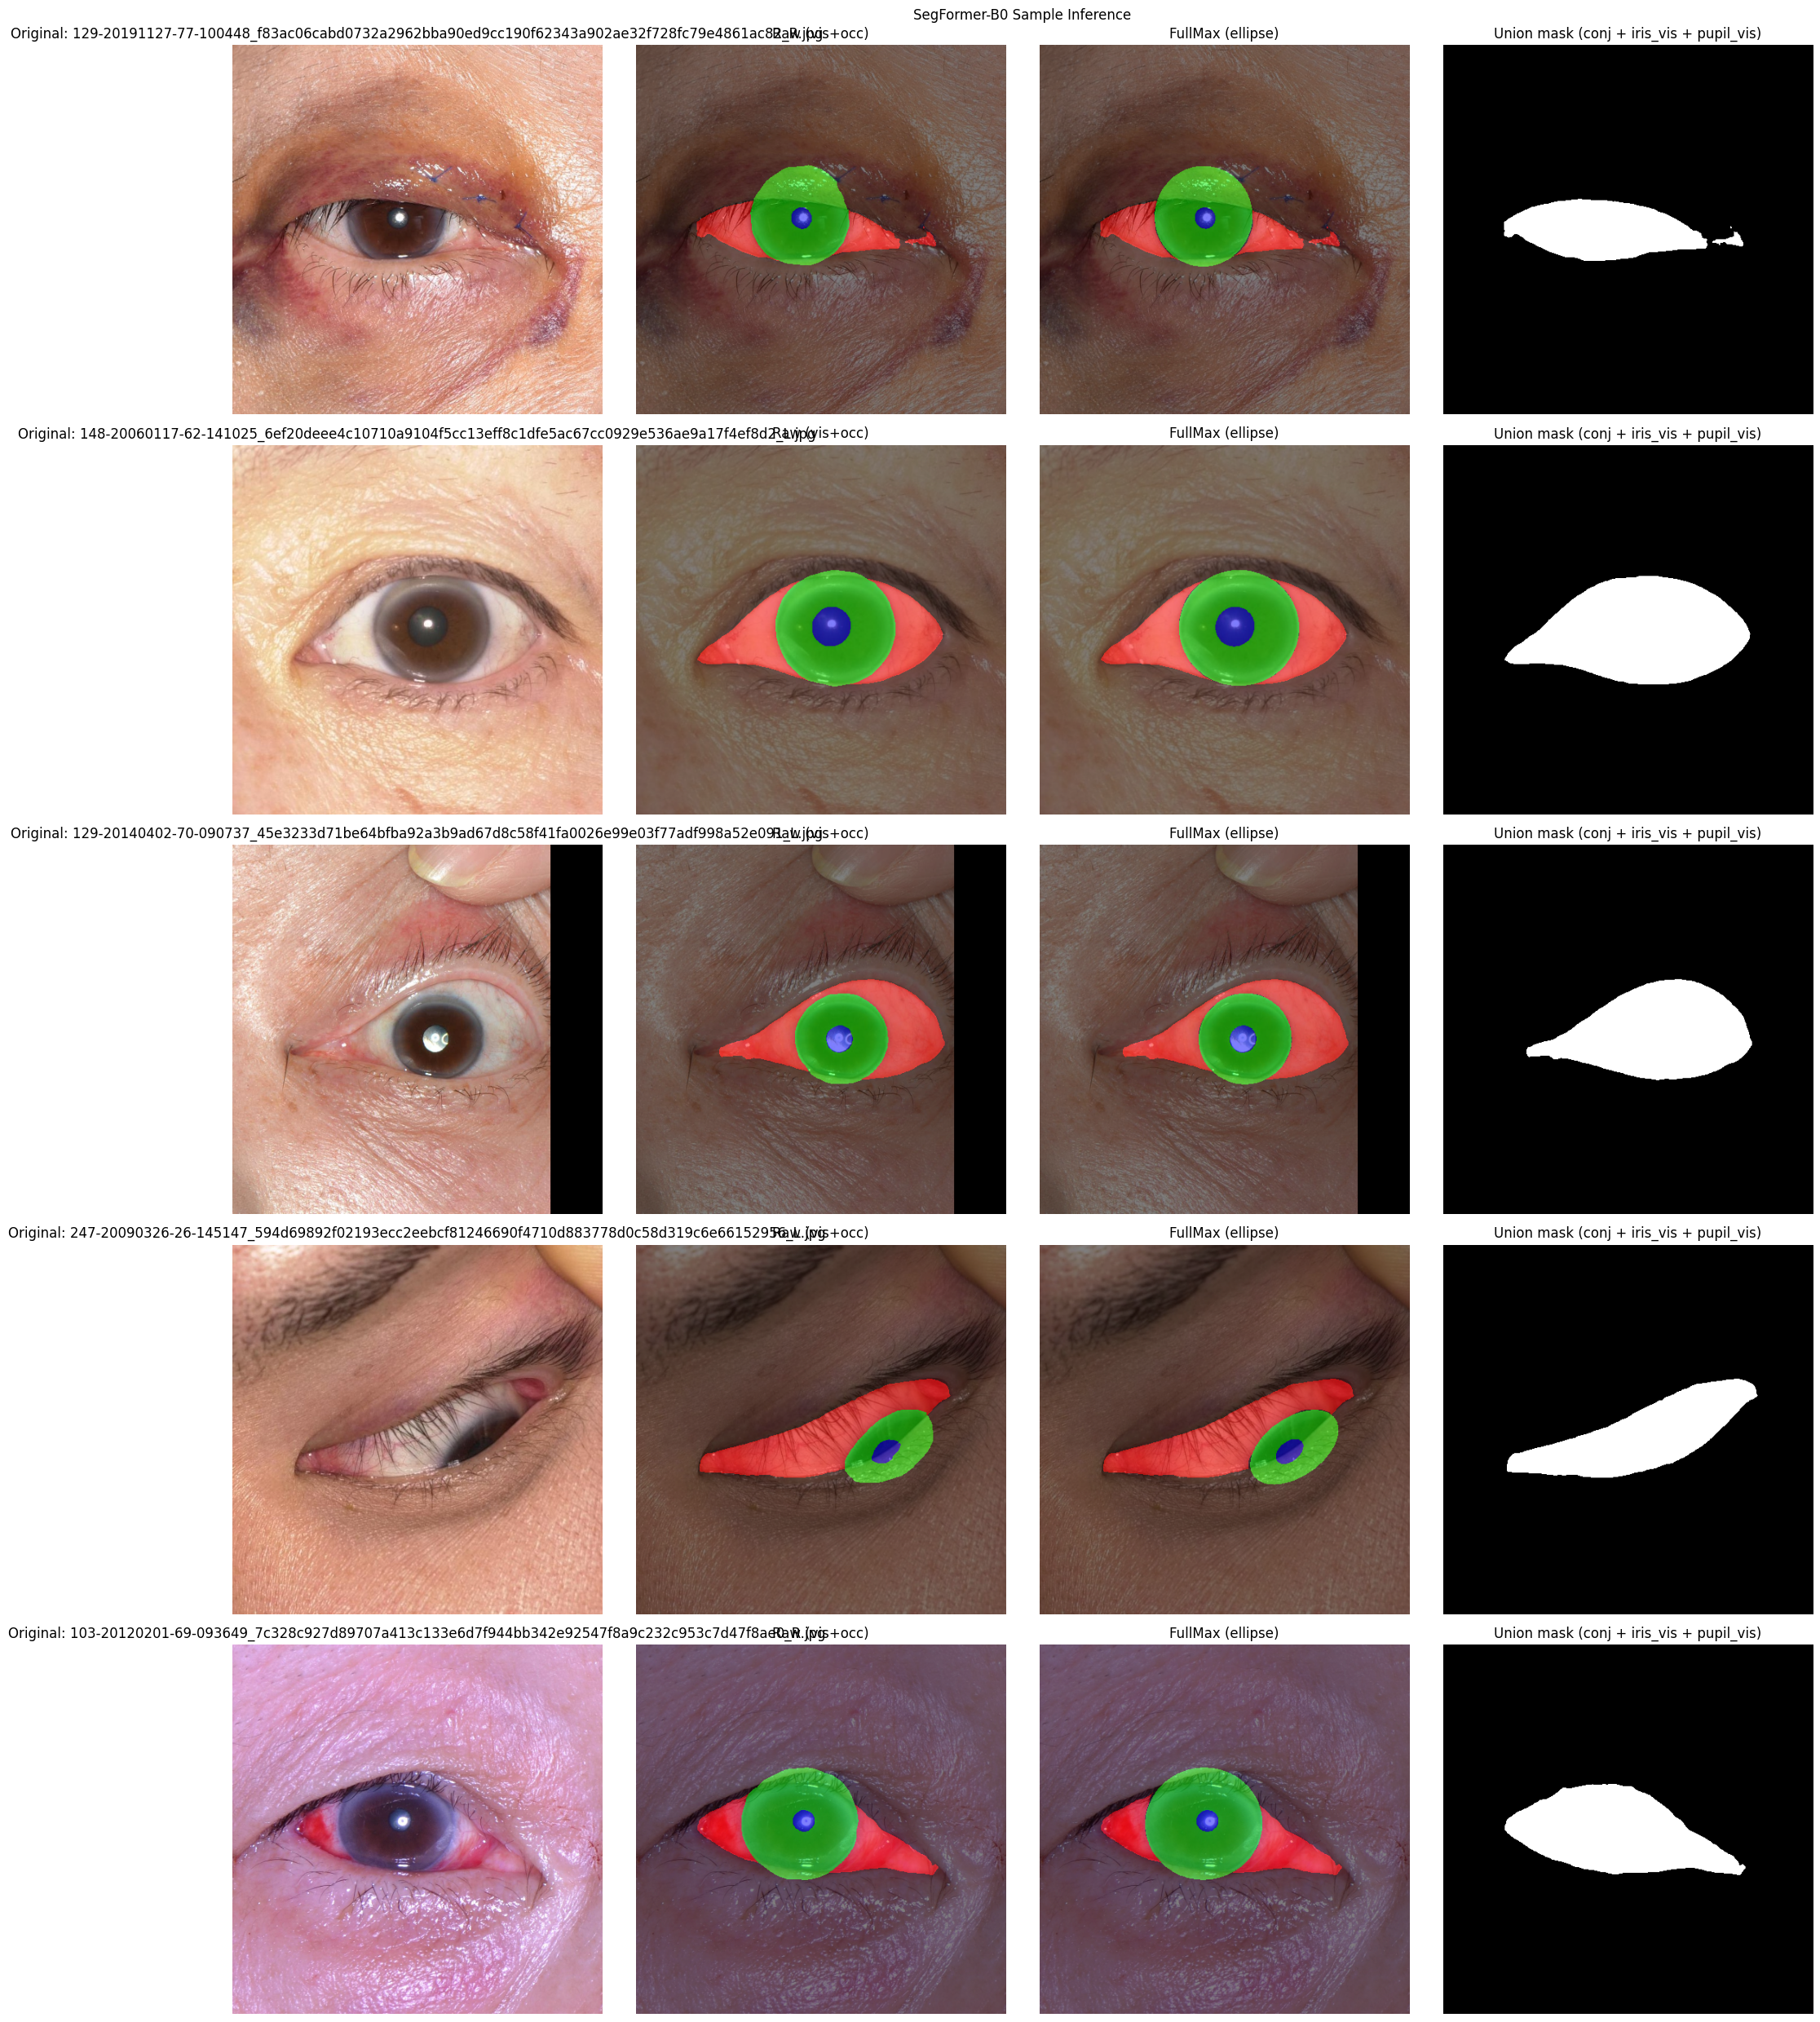

Visualization saved to: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0\results\inference_visualization.png


In [19]:
# ===== Cell 14: Inference Visualization =====
def visualize_samples(model, sample_names, title_prefix="SegFormer-B0", num_samples=5, random_seed=None):
    """Visualize inference results with random sample selection (same format as RF-DETR)."""
    # Randomly select samples from the validation set
    if random_seed is not None:
        np.random.seed(random_seed)
    indices = np.random.choice(len(sample_names), size=min(num_samples, len(sample_names)), replace=False)
    samples = [sample_names[i] for i in indices]
    n = len(samples)
    
    fig, axes = plt.subplots(n, 4, figsize=(20, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for row, name in enumerate(samples):
        img_path = IMAGES_DIR / name
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE)), cv2.COLOR_BGR2RGB)
        
        class_masks = predict_segformer(model, img_path, device, IMAGE_SIZE)
        
        conj = class_masks["conj"]
        iris_vis = class_masks["iris_vis"]
        iris_occ = class_masks["iris_occ"]
        pupil_vis = class_masks["pupil_vis"]
        pupil_occ = class_masks["pupil_occ"]
        
        lid = conj
        iris_raw = ((iris_vis > 0) | (iris_occ > 0)).astype(np.uint8) * 255
        pupil_raw = ((pupil_vis > 0) | (pupil_occ > 0)).astype(np.uint8) * 255
        
        iris_fullmax = fit_ellipse_mask(iris_raw)
        pupil_fullmax = fit_ellipse_mask(pupil_raw)
        
        union_vis = ((conj > 0) | (iris_vis > 0) | (pupil_vis > 0)).astype(np.uint8) * 255
        
        overlay_raw = make_overlay(img_rgb, lid, iris_raw, pupil_raw)
        overlay_fullmax = make_overlay(img_rgb, lid, iris_fullmax, pupil_fullmax)
        
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f"Original: {name}")
        axes[row, 0].axis("off")
        
        axes[row, 1].imshow(overlay_raw)
        axes[row, 1].set_title("Raw (vis+occ)")
        axes[row, 1].axis("off")
        
        axes[row, 2].imshow(overlay_fullmax)
        axes[row, 2].set_title("FullMax (ellipse)")
        axes[row, 2].axis("off")
        
        axes[row, 3].imshow(union_vis, cmap="gray", vmin=0, vmax=255)
        axes[row, 3].set_title("Union mask (conj + iris_vis + pupil_vis)")
        axes[row, 3].axis("off")
    
    plt.suptitle(f"{title_prefix} Sample Inference", y=0.99)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "inference_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Visualization saved to: {RESULTS_DIR / 'inference_visualization.png'}")


print("Running inference visualization...")
visualize_samples(model, val_names, title_prefix="SegFormer-B0", num_samples=5)

In [16]:
# ===== Cell 15: DICE Evaluation =====
def compute_dice(pred_mask, gt_mask):
    """Compute Dice coefficient."""
    pred = (pred_mask > 0).astype(np.float32)
    gt = (gt_mask > 0).astype(np.float32)
    
    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum()
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    
    return (2 * intersection) / union


def evaluate_dice_on_dataset(model, image_names, device):
    """Evaluate Dice scores on dataset."""
    results = []
    
    for name in tqdm(image_names, desc="Evaluating DICE"):
        img_path = IMAGES_DIR / name
        
        # Prediction
        class_masks = predict_segformer(model, img_path, device, IMAGE_SIZE)
        
        # Ground truth from XML (generate at original resolution, then resize)
        img = cv2.imread(str(img_path))
        orig_h, orig_w = img.shape[:2]
        gt_mask = generate_sixcls_mask_from_xml(
            name, orig_h, orig_w, 
            EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE
        )
        gt_mask = cv2.resize(gt_mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
        
        gt_conj = (gt_mask == 1).astype(np.uint8) * 255
        gt_iris = ((gt_mask == 2) | (gt_mask == 3)).astype(np.uint8) * 255
        gt_pupil = ((gt_mask == 4) | (gt_mask == 5)).astype(np.uint8) * 255
        
        pred_lid = class_masks["conj"]
        pred_iris_raw = ((class_masks["iris_vis"] > 0) | (class_masks["iris_occ"] > 0)).astype(np.uint8) * 255
        pred_pupil_raw = ((class_masks["pupil_vis"] > 0) | (class_masks["pupil_occ"] > 0)).astype(np.uint8) * 255
        
        pred_iris_fullmax = fit_ellipse_mask(pred_iris_raw)
        pred_pupil_fullmax = fit_ellipse_mask(pred_pupil_raw)
        
        result = {
            "image": name,
            "dice_lid": compute_dice(pred_lid, gt_conj),
            "dice_iris_raw": compute_dice(pred_iris_raw, gt_iris),
            "dice_pupil_raw": compute_dice(pred_pupil_raw, gt_pupil),
            "dice_iris_fullmax": compute_dice(pred_iris_fullmax, gt_iris),
            "dice_pupil_fullmax": compute_dice(pred_pupil_fullmax, gt_pupil),
        }
        
        result["dice_mean_raw"] = (result["dice_lid"] + result["dice_iris_raw"] + result["dice_pupil_raw"]) / 3
        result["dice_mean_fullmax"] = (result["dice_lid"] + result["dice_iris_fullmax"] + result["dice_pupil_fullmax"]) / 3
        
        results.append(result)
    
    results_df = pd.DataFrame(results)
    
    summary = {
        "dice_lid": results_df["dice_lid"].mean(),
        "dice_lid_std": results_df["dice_lid"].std(),
        "dice_iris_raw": results_df["dice_iris_raw"].mean(),
        "dice_iris_raw_std": results_df["dice_iris_raw"].std(),
        "dice_pupil_raw": results_df["dice_pupil_raw"].mean(),
        "dice_pupil_raw_std": results_df["dice_pupil_raw"].std(),
        "dice_iris_fullmax": results_df["dice_iris_fullmax"].mean(),
        "dice_iris_fullmax_std": results_df["dice_iris_fullmax"].std(),
        "dice_pupil_fullmax": results_df["dice_pupil_fullmax"].mean(),
        "dice_pupil_fullmax_std": results_df["dice_pupil_fullmax"].std(),
        "dice_mean_raw": results_df["dice_mean_raw"].mean(),
        "dice_mean_raw_std": results_df["dice_mean_raw"].std(),
        "dice_mean_fullmax": results_df["dice_mean_fullmax"].mean(),
        "dice_mean_fullmax_std": results_df["dice_mean_fullmax"].std(),
    }
    
    return results_df, summary


print("Evaluating DICE on validation set...")
results_df, summary = evaluate_dice_on_dataset(model, val_names, device)

results_df.to_csv(RESULTS_DIR / "dice_evaluation.csv", index=False)

print("\n" + "="*60)
print("DICE Evaluation Summary (Validation Set)")
print("="*60)
print(f"\nRaw Predictions:")
print(f"  Eyelid:  {summary['dice_lid']:.4f} +/- {summary['dice_lid_std']:.4f}")
print(f"  Iris:    {summary['dice_iris_raw']:.4f} +/- {summary['dice_iris_raw_std']:.4f}")
print(f"  Pupil:   {summary['dice_pupil_raw']:.4f} +/- {summary['dice_pupil_raw_std']:.4f}")
print(f"  Mean:    {summary['dice_mean_raw']:.4f} +/- {summary['dice_mean_raw_std']:.4f}")

print(f"\nFullMax (Ellipse Fitted):")
print(f"  Eyelid:  {summary['dice_lid']:.4f} +/- {summary['dice_lid_std']:.4f}")
print(f"  Iris:    {summary['dice_iris_fullmax']:.4f} +/- {summary['dice_iris_fullmax_std']:.4f}")
print(f"  Pupil:   {summary['dice_pupil_fullmax']:.4f} +/- {summary['dice_pupil_fullmax_std']:.4f}")
print(f"  Mean:    {summary['dice_mean_fullmax']:.4f} +/- {summary['dice_mean_fullmax_std']:.4f}")

print(f"\nResults saved to: {RESULTS_DIR / 'dice_evaluation.csv'}")

Evaluating DICE on validation set...


Evaluating DICE:   0%|          | 0/574 [00:00<?, ?it/s]


DICE Evaluation Summary (Validation Set)

Raw Predictions:
  Eyelid:  0.9392 +/- 0.1283
  Iris:    0.9439 +/- 0.0901
  Pupil:   0.9121 +/- 0.1488
  Mean:    0.9317 +/- 0.0894

FullMax (Ellipse Fitted):
  Eyelid:  0.9392 +/- 0.1283
  Iris:    0.9027 +/- 0.0877
  Pupil:   0.9138 +/- 0.1480
  Mean:    0.9186 +/- 0.0847

Results saved to: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0\results\dice_evaluation.csv


In [17]:
# ===== Cell 16: Final Summary =====
print("\n" + "="*60)
print("SegFormer-B0 Training Complete")
print("="*60)
print(f"\nModel: {SEGFORMER_MODEL_NAME}")
print(f"Dataset: {len(train_names)} train / {len(val_names)} val images")
print(f"Total: {len(train_names) + len(val_names)} images")
print(f"Best epoch: {best_epoch}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"\nOutputs:")
print(f"  Model: {MODEL_DIR / 'segformer_b0_best.pth'}")
print(f"  Loss plot: {RESULTS_DIR / 'training_loss.png'}")
print(f"  Visualization: {RESULTS_DIR / 'inference_visualization.png'}")
print(f"  DICE results: {RESULTS_DIR / 'dice_evaluation.csv'}")
print(f"\nMean DICE (FullMax): {summary['dice_mean_fullmax']:.4f}")


SegFormer-B0 Training Complete

Model: nvidia/segformer-b0-finetuned-ade-512-512
Dataset: 2426 train / 574 val images
Total: 3000 images


NameError: name 'best_epoch' is not defined

---
# Real-World Inference Test
Periocular領域検出 + 学習したモデルでのセグメンテーション推論

Loading models...
  YOLO classes: {0: 'Right_eye', 1: 'Left_eye'}

sample_image.png
Detected 2 eyes
  Right_eye: Eyelid=6.0%, Iris=7.2%, Pupil=0.8%
  Left_eye: Eyelid=7.3%, Iris=10.9%, Pupil=1.4%


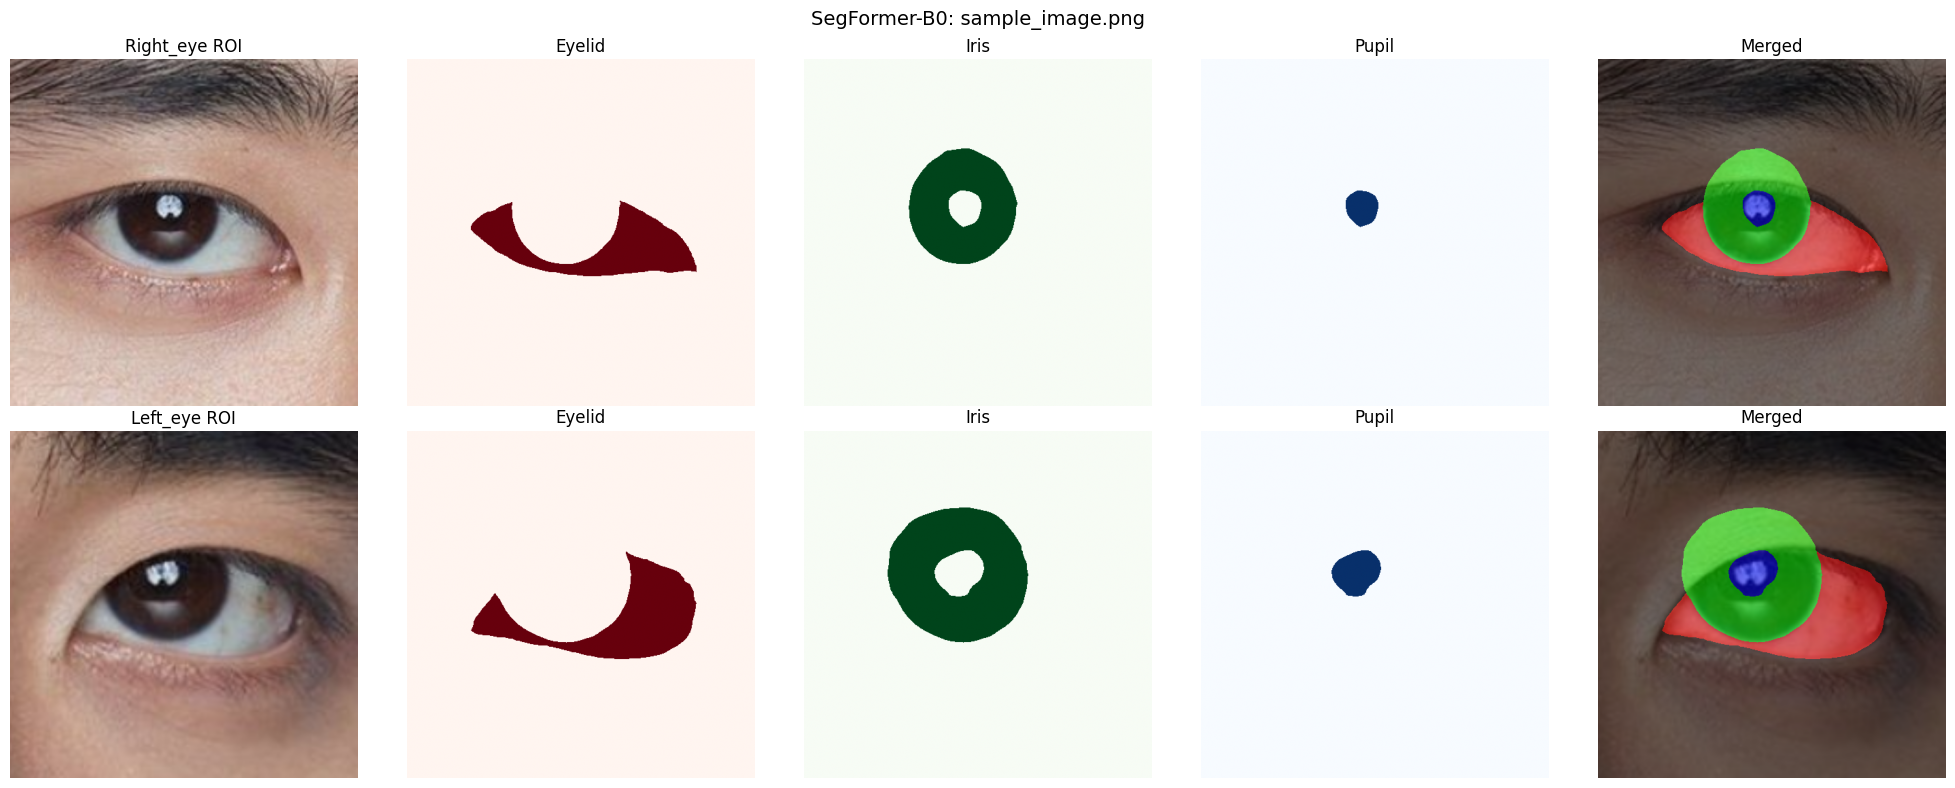


sample_image_2.png
Detected 2 eyes
  Right_eye: Eyelid=4.4%, Iris=7.8%, Pupil=1.1%
  Left_eye: Eyelid=4.3%, Iris=9.4%, Pupil=1.1%


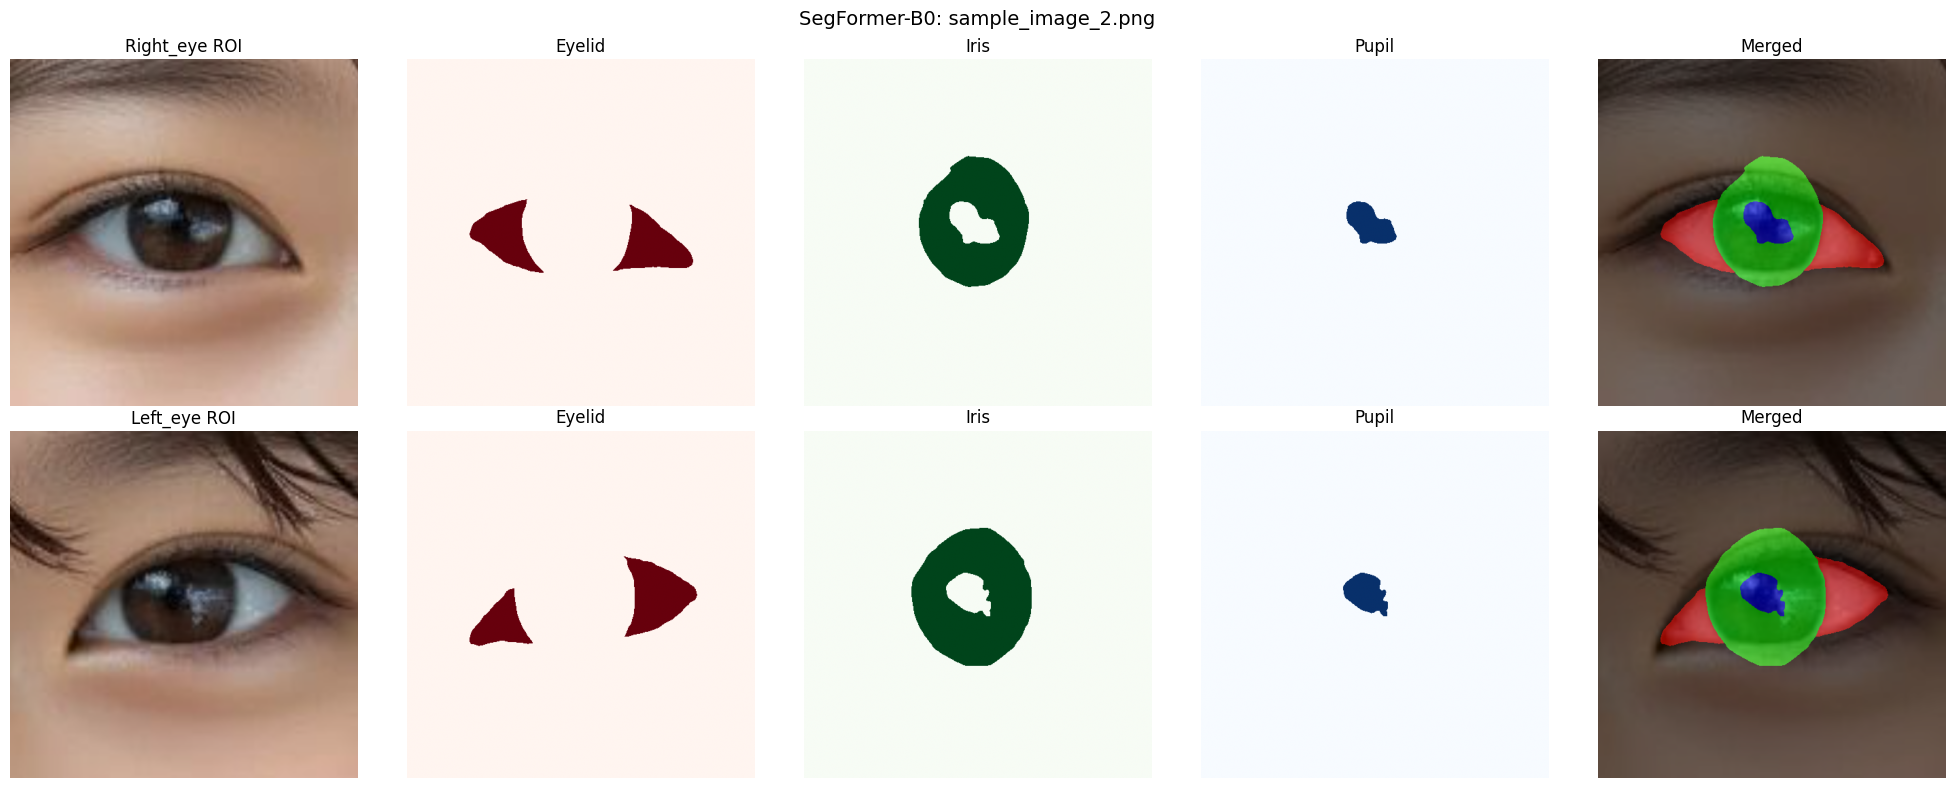

In [18]:
# ===== Cell 17: Real-World Inference Test =====
# Periocular領域検出＋学習したモデルでセグメンテーション推論を実行
# このセル単体でも実行可能

import sys
if 'cv2' not in sys.modules:
    import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
from ultralytics import YOLO

# === 設定 ===
PROJECT_ROOT = Path(".").resolve()
PERIOCULAR_DIR = PROJECT_ROOT / "Periocular_detection"
DETECT_MODEL_PATH = PERIOCULAR_DIR / "YOLO11l-detect.pt"
SAMPLE_IMAGES = [PERIOCULAR_DIR / "sample_image.png", PERIOCULAR_DIR / "sample_image_2.png"]
SEGFORMER_MODEL_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"
IMAGE_SIZE, EXPANSION_RATIO = 512, 0.25
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Helper Functions ===
def extract_roi(image, bbox, roi_size=512, expansion_ratio=0.25):
    h, w = image.shape[:2]
    x1, y1, x2, y2 = bbox
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    side = max(x2 - x1, y2 - y1) * (1 + 2 * expansion_ratio)
    nx1, ny1 = int(cx - side / 2), int(cy - side / 2)
    nx2, ny2 = int(cx + side / 2), int(cy + side / 2)
    pad_top, pad_bottom = max(0, -ny1), max(0, ny2 - h)
    pad_left, pad_right = max(0, -nx1), max(0, nx2 - w)
    roi = image[max(0, ny1):min(h, ny2), max(0, nx1):min(w, nx2)].copy()
    if pad_top or pad_bottom or pad_left or pad_right:
        roi = cv2.copyMakeBorder(roi, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=[0,0,0])
    return cv2.resize(roi, (roi_size, roi_size))

def predict_sixcls(seg_model, roi_rgb, device, image_size=512):
    """Run SegFormer 6-class inference on a single ROI image."""
    processor = SegformerImageProcessor.from_pretrained(SEGFORMER_MODEL_NAME, do_resize=False, do_rescale=True, do_normalize=True)
    inputs = processor(images=roi_rgb, return_tensors="pt")
    with torch.no_grad():
        logits = seg_model(pixel_values=inputs["pixel_values"].to(device)).logits
        if logits.shape[-2:] != (image_size, image_size):
            logits = F.interpolate(logits, size=(image_size, image_size), mode='bilinear', align_corners=False)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    # Extract masks from 6-class prediction
    conj = (pred == 1).astype(np.uint8) * 255
    iris = ((pred == 2) | (pred == 3)).astype(np.uint8) * 255  # iris_vis + iris_occ
    pupil = ((pred == 4) | (pred == 5)).astype(np.uint8) * 255  # pupil_vis + pupil_occ
    
    return {'eyelid': conj, 'iris': iris, 'pupil': pupil}

def create_overlay(img_rgb, masks, alpha=0.5):
    h, w = img_rgb.shape[:2]
    color = np.zeros((h, w, 3), dtype=np.float32)
    color[masks['eyelid'] > 0, 0] = 255
    color[masks['iris'] > 0, 1] = 255
    color[masks['pupil'] > 0, 2] = 255
    return np.clip(img_rgb.astype(np.float32) * (1 - alpha) + color * alpha, 0, 255).astype(np.uint8)

# === Load Models ===
print("Loading models...")
detect_model = YOLO(str(DETECT_MODEL_PATH))

# Load SegFormer model (use existing 'model' if available, otherwise load from checkpoint)
if 'model' not in dir() or model is None:
    MODEL_DIR = PROJECT_ROOT / "Ablation_SegFormerB0" / "models"
    model_path = MODEL_DIR / "segformer_b0_best.pth"
    model = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model"])
    model.eval()
    print(f"  Loaded SegFormer from: {model_path.name}")
print(f"  YOLO classes: {detect_model.names}")

# === Run Pipeline ===
for img_path in SAMPLE_IMAGES:
    if not img_path.exists():
        print(f"Image not found: {img_path}")
        continue
    
    print(f"\n{'='*50}\n{img_path.name}\n{'='*50}")
    img = cv2.imread(str(img_path))
    detections = detect_model.predict(source=img, conf=0.25, iou=0.45, verbose=False)[0]
    print(f"Detected {len(detections.boxes)} eyes")
    
    if len(detections.boxes) == 0:
        continue
    
    results = []
    for box in detections.boxes:
        eye_name = detect_model.names[int(box.cls[0])]
        roi = extract_roi(img, box.xyxy[0].cpu().numpy(), IMAGE_SIZE, EXPANSION_RATIO)
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        masks = predict_sixcls(model, roi_rgb, device, IMAGE_SIZE)
        results.append({'name': eye_name, 'roi': roi_rgb, 'masks': masks})
        print(f"  {eye_name}: Eyelid={100*(masks['eyelid']>0).mean():.1f}%, Iris={100*(masks['iris']>0).mean():.1f}%, Pupil={100*(masks['pupil']>0).mean():.1f}%")
    
    n = len(results)
    fig, axes = plt.subplots(n, 5, figsize=(20, 4*n))
    if n == 1: axes = axes.reshape(1, -1)
    for i, res in enumerate(results):
        axes[i,0].imshow(res['roi']); axes[i,0].set_title(f"{res['name']} ROI"); axes[i,0].axis('off')
        axes[i,1].imshow(res['masks']['eyelid'], cmap='Reds', vmin=0, vmax=255); axes[i,1].set_title('Eyelid'); axes[i,1].axis('off')
        axes[i,2].imshow(res['masks']['iris'], cmap='Greens', vmin=0, vmax=255); axes[i,2].set_title('Iris'); axes[i,2].axis('off')
        axes[i,3].imshow(res['masks']['pupil'], cmap='Blues', vmin=0, vmax=255); axes[i,3].set_title('Pupil'); axes[i,3].axis('off')
        axes[i,4].imshow(create_overlay(res['roi'], res['masks'])); axes[i,4].set_title('Merged'); axes[i,4].axis('off')
    plt.suptitle(f"SegFormer-B0: {img_path.name}", fontsize=14)
    plt.tight_layout()
    plt.show()